In [34]:
import sys
import os
sys.path.append(os.path.abspath("../../src"))

import scanpy as sc
from dmt import DyMoTree

adata = sc.read_h5ad('../../data/case/LungCancer/anndata/anndata.h5ad')
dmt = DyMoTree(adata=adata,
               k=40,
               progenitor='Transitional',
               terminal=['AT1','EMT'],
               lineage_col='lineage',
               emb_key='emb',
               device='cuda',
               seed=42)

dmt.lineage_graph(mask_threshold=0.8, epsilon=1, mode='composite')

Successfully loaded state: Transitional, cells: 765
Successfully loaded state: AT1, cells: 193
Successfully loaded state: EMT, cells: 89
--- Start Building Lineage Graph ---
[*] Intra-state graph built for 'Transitional' (Edges: 29835)
[*] Intra-state graph built for 'AT1' (Edges: 7527)
[*] Intra-state graph built for 'EMT' (Edges: 3471)
[*] Calculating composite similarity between progenitor 'Transitional' and terminals ['AT1', 'EMT']...
[*] Inter-state graph built for 'AT1' (Edges: 60405)
[*] Inter-state graph built for 'EMT' (Edges: 27675)


In [35]:
dmt.train(pre_train = 'combined',
              lr = {'formal':1e-4,
                    'intra':1e-3,
                    'lineage':1e-4},
              iter = {'formal':350,
                    'intra':100,
                    'lineage':350},
              sample_ratio = 256,
              alpha = 0)

:: Stage1 Pre-training -- intra-state transition graph::
:: Do pre-train Graph encoder for Transitional ::


100%|█████████████████████████████████████████████████| 100/100 [00:03<00:00, 25.04it/s, loss=0.655]


:: Do pre-train Graph encoder for AT1 ::


100%|█████████████████████████████████████████████████| 100/100 [00:01<00:00, 62.55it/s, loss=0.833]


:: Do pre-train Graph encoder for EMT ::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 350/350 : 100%|█████████████████████████████████| 350/350 [00:22<00:00, 15.78it/s, loss=0.418]


:: DyMoTree Training::


Iter: 350/350 : 100%|█████████████████████████████████| 350/350 [00:21<00:00, 15.97it/s, loss=0.724]

[2026-04-13 20:54:41] get fate space of Transitional


In [37]:
import scanpy as sc
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.5,"white"), (1,"#c42238")]
)

progenitor = dmt.treedata.get_node('Transitional',adata_object=True)
progenitor.obs['fate_bias'] = dmt.cal_fate_bias(progenitor.obs['EMT_fate'], progenitor.obs['AT1_fate'])
sc.pl.embedding(progenitor, basis='plt', color=['fate_bias'], show=False,cmap=custom_bwr,vcenter=0.5,size=40)




<Axes: title={'center': 'fate_bias'}, xlabel='plt1', ylabel='plt2'>

In [6]:
# find cell state
dmt.find_state(n_state=3,
               n_pca=5,
               n_diff=5,
               n_gene=10,
               method='spearman')

[2026-04-13 10:47:04] find cell state of Transitional
[2026-04-13 10:47:04] Filtering Data by fate space
[2026-04-13 10:47:08] PCA transformation
[2026-04-13 10:47:09] Run Diffusion map
[2026-04-13 10:47:10] Find archetypes


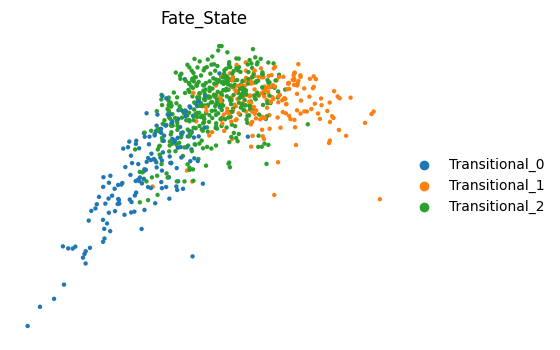

In [8]:
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.embedding(
        dmt.treedata.get_node('Transitional',adata_object=True),
        basis='plt',
        color='Fate_State', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

/tmp/ipykernel_2227165/2420158651.py:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)
/tmp/ipykernel_2227165/2420158651.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['Fate_State'] = adata.obs['Fate_State'].replace(replacement_map_adata)


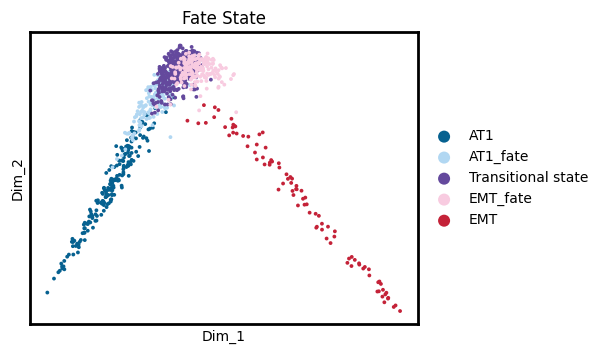

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import scanpy as sc
import anndata
import pandas as pd

adata_merged = anndata.concat(
    [dmt.treedata.get_node(cell,adata_object=True) for cell in dmt.model.tree.keys()]
)
adata_to_plot = adata_merged.copy()
adata = dmt.treedata.get_node('Transitional',adata_object=True).copy()

# rename DyMoTree Cell State
import pandas as pd
replacement_map = {'Transitional_0': 'AT1_fate', 'Transitional_1': 'EMT_fate','Transitional_2':'Transitional state','EMT':'EMT','AT1':'AT1'}
replacement_map_adata = {'Transitional_0': 'AT1_fate', 'Transitional_1': 'EMT_fate','Transitional_2':'Transitional state'}
new_order = ['AT1','AT1_fate','Transitional state','EMT_fate','EMT']
new_order_adata = ['AT1_fate','Transitional state','EMT_fate']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].replace(replacement_map)
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))

adata.obs['Fate_State'] = adata.obs['Fate_State'].astype('category')
adata.obs['Fate_State'] = adata.obs['Fate_State'].replace(replacement_map_adata)
adata.obs['Fate_State'] = adata.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))

adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype('category')
new_order = ['AT1','AT1_fate','Transitional state','EMT_fate','EMT']
adata_to_plot.obs['Fate_State'] = adata_to_plot.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype('category')
new_order = ['AT1','Transitional','EMT']
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))


adata.obs['Fate_State'] = adata.obs['Fate_State'].astype('category')
new_order_adata = ['AT1_fate','Transitional state','EMT_fate']
adata.obs['Fate_State'] = adata.obs['Fate_State'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))
adata.obs['lineage'] = adata.obs['lineage'].astype('category')
new_order_adata = ['Transitional']
adata.obs['lineage'] = adata.obs['lineage'].astype(pd.CategoricalDtype(categories=new_order_adata, ordered=True))

color_map_state = {
    'AT1_fate': '#b1d7f2',
    'Transitional state': '#64499d',
    'EMT_fate': '#f8cbe0',
    'AT1':'#066190',
    'EMT':'#c42238'
}
 
color_map_state_adata = {
    'AT1_fate': '#b1d7f2',
    'Transitional state': '#64499d',
    'EMT_fate': '#f8cbe0'
}
state_color_list = [color_map_state[cat] for cat in adata_to_plot.obs['Fate_State'].cat.categories]
adata_to_plot.uns['Fate_State_colors'] = state_color_list
state_color_list_adata = [color_map_state_adata[cat] for cat in adata.obs['Fate_State'].cat.categories]
adata.uns['Fate_State_colors'] = state_color_list_adata

color_map_celltype_adata = {
    'Transitional': '#64499d'
}
color_map_celltype = {
    'Transitional': '#64499d',
    'AT1':'#066190',
    'EMT':'#c42238'
}
celltype_color_list = [color_map_celltype[cat] for cat in adata_to_plot.obs['lineage'].cat.categories]
adata_to_plot.uns['lineage_colors'] = celltype_color_list
celltype_color_list = [color_map_celltype_adata[cat] for cat in adata.obs['lineage'].cat.categories]
adata.uns['lineage_colors'] = celltype_color_list


with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        adata_to_plot,
        x='Dim_1',
        y='Dim_2',
        color='Fate_State',  
        size=30,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig("./Fig4/LC.Transitional.pdf",bbox_inches='tight')
    plt.show()

In [1]:
import scanpy as sc
adata_to_plot = sc.read_h5ad('./LungCancer_result.h5ad')

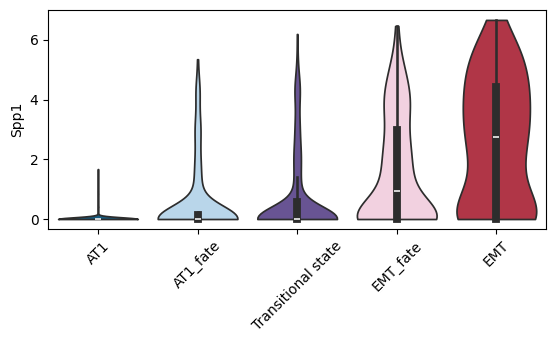

In [27]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

#tree = sc.read('./Fig4/LC_dmt.h5ad')
#stem = sc.read('D:/scRNA/LungCancer/Result.DyMoTree.10.14/transitional_dmt.h5ad')
gene = 'Spp1'
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        adata_to_plot,
        gene,
        groupby='Fate_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    plt.savefig(f"./LC.{gene}_expression_fate_State.pdf",bbox_inches='tight')
    plt.show()

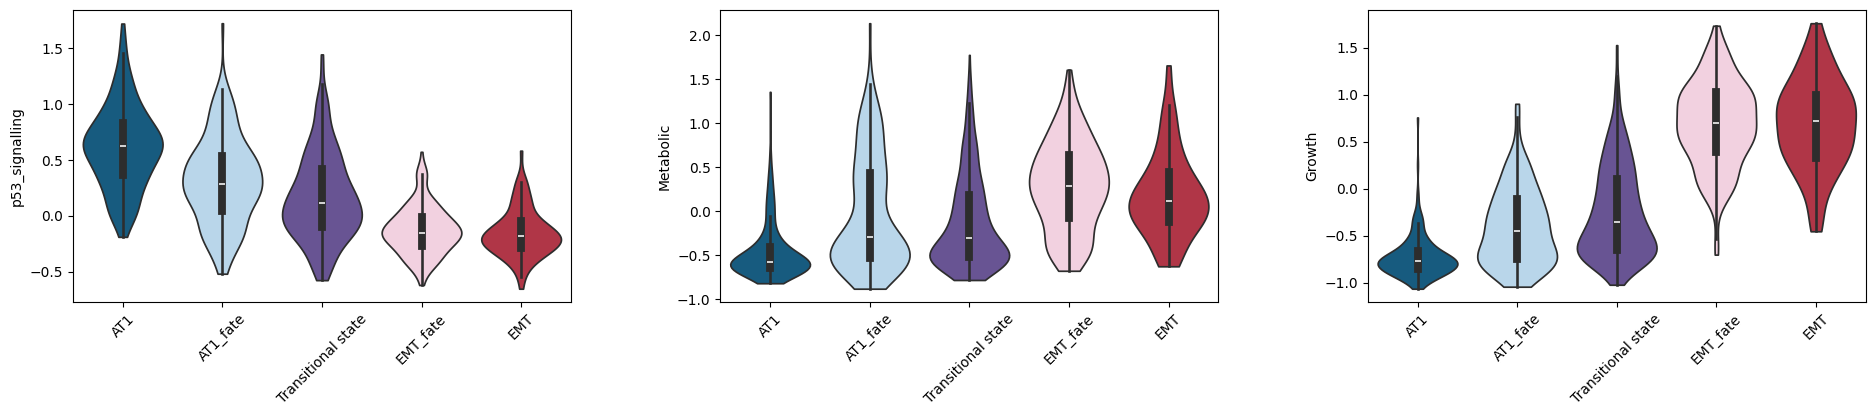

In [23]:
gene_sets = {
    'p53_signalling': [
    'Cdkn1a',  
    'Mdm2', 'Bax', 'Ccng1',  
    'Phlda3', 'Zmat3', 'Ptpn14', 'Abhd4', 
    'Fam174b', 'Pdgfa', 'Crip2', 'Timp3'
],
    'Metabolic': ['Serinc3', 'Tpi1', 'Rbp4', 'Vsig2', 'Rbp1'],
    'Growth': ['Ctse', 'Igfbp3', 'Gpa33', 'Slc4a8', 'Hnf4a']
}

for name, genes in gene_sets.items():
    genes_in_data = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, gene_list=genes_in_data, score_name=name)
    sc.tl.score_genes(adata_to_plot, gene_list=genes_in_data, score_name=name)
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context

# --- 三个功能模块 ---
features = ['p53_signalling', 'Metabolic', 'Growth']
group_col = 'Fate_State'

# --- 一次性绘制三个分组小提琴图 ---
with rc_context({'figure.figsize': (6, 4)}):  # 控制图大小
    sc.pl.violin(
        adata_to_plot,
        keys=features,            # 一次性输入多个功能名
        groupby=group_col,        # 分组列
        stripplot=False,          # 不叠加散点
        inner='box',              # 显示箱线
        rotation=45,              # x轴标签旋转
        show=False,
        multi_panel=True,         # 分面显示，每个功能一个面板
    )
#plt.savefig("./Fig4/LC.core_pathway_fate_state.pdf",bbox_inches='tight')

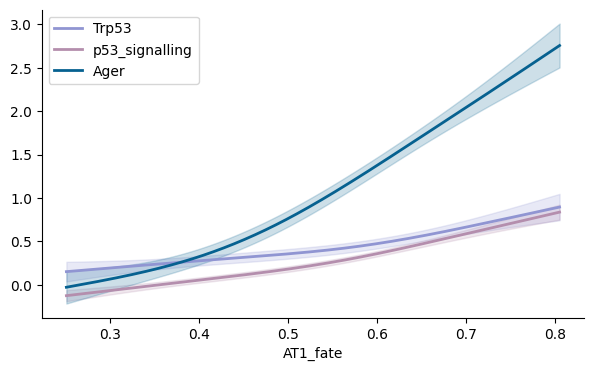

In [25]:
#from plotting import plot_feature_trend
import scanpy as sc
from pygam import LinearGAM, s

stem = dmt.treedata.get_node('Transitional',adata_object=True).copy()
features = ['Trp53','p53_signalling','Ager']
corrected_p53_genes = [
    'Cdkn1a',  
    'Mdm2', 'Bax', 'Ccng1',  
    'Phlda3', 'Zmat3', 'Ptpn14', 'Abhd4', 
    'Fam174b', 'Pdgfa', 'Crip2', 'Timp3'
]
color_map = {features[0]:"#9095d2",features[1]:"#b48ead",features[2]:"#066190"}
sc.tl.score_genes(stem, corrected_p53_genes, score_name='p53_signalling')
#features = ['Elane','Gfi1','Mpo']
#color_map = {features[0]:'#fd738a',features[1]:'#fea6b6',features[2]:'#ff4a4a'}
def plot_feature_trend(adata,pseudotime_key,features,color_map,lin_space=200,n_splines=20,lam=50,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(5, 3),show=True):
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    colors = plt.cm.viridis(np.linspace(0, 1, len(features)))
    # --- 4. 循环遍历并绘图 ---
    for i, gene_name in enumerate(features):
    
        x_pseudotime = adata.obs[pseudotime_key].values
        if gene_name in adata.var_names:
            y_expression = adata[:, gene_name].X.toarray().flatten() if hasattr(adata[:, gene_name].X, 'toarray') else adata[:, gene_name].X.flatten()
        else:
            y_expression = adata.obs[gene_name].values

        if len(x_pseudotime) < 15:
            continue
            
        gam = LinearGAM(s(0, n_splines=n_splines, lam=lam)).fit(x_pseudotime, y_expression)
        x_smooth = np.linspace(x_pseudotime.min(), x_pseudotime.max(), lin_space)
        y_smooth = gam.predict(x_smooth)
        intervals = gam.confidence_intervals(x_smooth, width=confidence_level)
        
        
        # 1. 绘制趋势线，并为其分配 label 以便生成图例
        ax.plot(
            x_smooth, 
            y_smooth, 
            linewidth=linewidth, 
            label=gene_name,  # <-- 关键：label 在这里
            color=color_map[gene_name]
        )
        
        # 2. 绘制置信区间，不分配 label
        ax.fill_between(
            x_smooth, 
            intervals[:, 0], 
            intervals[:, 1], 
            color=color_map[gene_name],
            alpha=alpha 
        )
    # 去掉顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.set_ylabel('Gene Expression')
    ax.set_xlabel(pseudotime_key)
    ax.legend()
    if show:
        # --- 6. 最终调整 ---
        plt.tight_layout()
        plt.show()
    else:
        return ax
ax = plot_feature_trend(stem,'AT1_fate',features,color_map,lin_space=1000,n_splines=10,lam=100,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(7, 4),show=False)
#plt.savefig("./Fig4/LC.p53_signalling_AT1_trends.png",bbox_inches='tight')
plt.show()

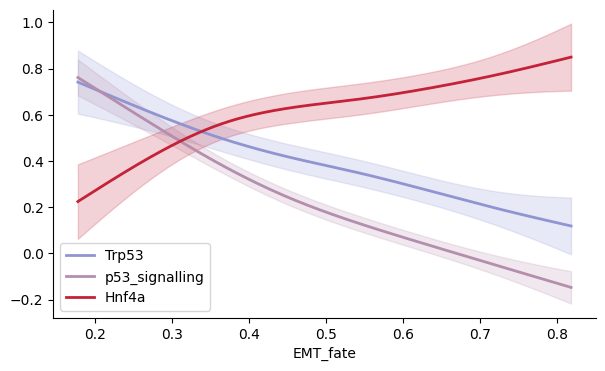

In [26]:
#from plotting import plot_feature_trend
import scanpy as sc
from pygam import LinearGAM, s

stem = dmt.treedata.get_node('Transitional',adata_object=True).copy()
features = ['Trp53','p53_signalling','Hnf4a']
corrected_p53_genes = [
    'Cdkn1a',  
    'Mdm2', 'Bax', 'Ccng1',  
    'Phlda3', 'Zmat3', 'Ptpn14', 'Abhd4', 
    'Fam174b', 'Pdgfa', 'Crip2', 'Timp3'
]
color_map = {features[0]:"#9095d2",features[1]:"#b48ead",features[2]:'#c42238'}
sc.tl.score_genes(stem, corrected_p53_genes, score_name='p53_signalling')
#features = ['Elane','Gfi1','Mpo']
#color_map = {features[0]:'#fd738a',features[1]:'#fea6b6',features[2]:'#ff4a4a'}
def plot_feature_trend(adata,pseudotime_key,features,color_map,lin_space=200,n_splines=20,lam=50,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(5, 3),show=True):
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    colors = plt.cm.viridis(np.linspace(0, 1, len(features)))
    # --- 4. 循环遍历并绘图 ---
    for i, gene_name in enumerate(features):
    
        x_pseudotime = adata.obs[pseudotime_key].values
        if gene_name in adata.var_names:
            y_expression = adata[:, gene_name].X.toarray().flatten() if hasattr(adata[:, gene_name].X, 'toarray') else adata[:, gene_name].X.flatten()
        else:
            y_expression = adata.obs[gene_name].values

        if len(x_pseudotime) < 15:
            continue
            
        gam = LinearGAM(s(0, n_splines=n_splines, lam=lam)).fit(x_pseudotime, y_expression)
        x_smooth = np.linspace(x_pseudotime.min(), x_pseudotime.max(), lin_space)
        y_smooth = gam.predict(x_smooth)
        intervals = gam.confidence_intervals(x_smooth, width=confidence_level)
        
        
        # 1. 绘制趋势线，并为其分配 label 以便生成图例
        ax.plot(
            x_smooth, 
            y_smooth, 
            linewidth=linewidth, 
            label=gene_name,  # <-- 关键：label 在这里
            color=color_map[gene_name]
        )
        
        # 2. 绘制置信区间，不分配 label
        ax.fill_between(
            x_smooth, 
            intervals[:, 0], 
            intervals[:, 1], 
            color=color_map[gene_name],
            alpha=alpha 
        )
    # 去掉顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.set_ylabel('Gene Expression')
    ax.set_xlabel(pseudotime_key)
    ax.legend()
    if show:
        # --- 6. 最终调整 ---
        plt.tight_layout()
        plt.show()
    else:
        return ax
ax = plot_feature_trend(stem,'EMT_fate',features,color_map,lin_space=1000,n_splines=10,lam=100,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(7, 4),show=False)
#plt.savefig("./Fig4/LC.p53_signalling_EMT_trends.png",bbox_inches='tight')
plt.show()

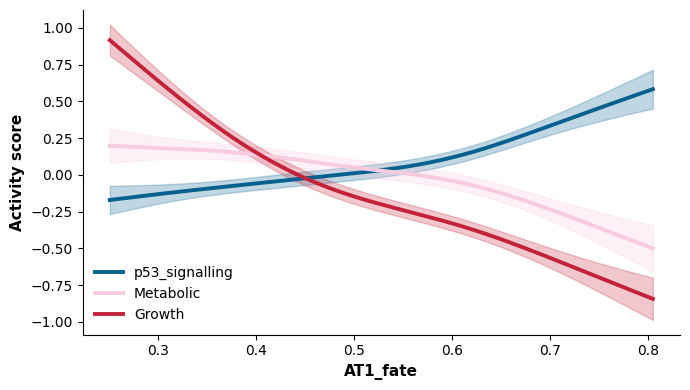

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
import scanpy as sc

# 提取对应 fate 的数据
adata_trend = dmt.treedata.get_node('Transitional',adata_object=True).copy()

# --- 三个功能模块 ---
features = ['p53_signalling', 'Metabolic', 'Growth']
color_map = {
    'p53_signalling': '#066190',  # 蓝色：p53通路
    'Metabolic': '#f8cbe0',       # 粉色：代谢
    'Growth': '#c42238'        # 红色：生长
}
color_map_state = {
    'AT1_fate': '#b1d7f2',
    'Transition state': '#64499d',
    'EMT_fate': '#f8cbe0',
    'AT1':'#066190',
    'EMT':'#c42238'
}
# 若功能评分列不存在，则重新计算
gene_sets = {
    'p53_signalling': ['Trp53', 'Phlda3', 'Prsc1', 'Ccng1', 'Zmat3'],
    'Metabolic': ['Serinc3', 'Tpi1', 'Rbp4', 'Vsig2', 'Rbp1'],
    'Growth': ['Ctse', 'Igfbp3', 'Gpa33', 'Slc4a8', 'Hnf4a']
}

for name, genes in gene_sets.items():
    genes_in_data = [g for g in genes if g in adata_trend.var_names]
    if name not in adata_trend.obs.columns:
        sc.tl.score_genes(adata_trend, gene_list=genes_in_data, score_name=name)

# --- 绘制函数 ---
def plot_feature_trend(adata, pseudotime_key, features, color_map,
                       lin_space=500, n_splines=15, lam=50,
                       confidence_level=0.95, alpha=0.25,
                       linewidth=2.5, figsize=(6, 4), show=True):
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    
    for feature in features:
        x = adata.obs[pseudotime_key].values
        if feature in adata.obs.columns:
            y = adata.obs[feature].values
        elif feature in adata.var_names:
            y = adata[:, feature].X.toarray().flatten() if hasattr(adata[:, feature].X, 'toarray') else adata[:, feature].X.flatten()
        else:
            continue

        gam = LinearGAM(s(0, n_splines=n_splines, lam=lam)).fit(x, y)
        x_smooth = np.linspace(x.min(), x.max(), lin_space)
        y_smooth = gam.predict(x_smooth)
        intervals = gam.confidence_intervals(x_smooth, width=confidence_level)

        ax.plot(x_smooth, y_smooth, color=color_map[feature],
                linewidth=linewidth, label=feature)
        ax.fill_between(x_smooth, intervals[:, 0], intervals[:, 1],
                        color=color_map[feature], alpha=alpha)
    
    # 优化外观
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(pseudotime_key, fontsize=11, weight='bold')
    ax.set_ylabel('Activity score', fontsize=11, weight='bold')
    ax.legend(frameon=False, fontsize=10)
    plt.tick_params(axis='both', labelsize=10)
    plt.tight_layout()
    
    if show:
        plt.show()
    else:
        return ax

# --- 绘制趋势图 ---
ax = plot_feature_trend(
    adata_trend,
    pseudotime_key='AT1_fate',
    features=features,
    color_map=color_map,
    lin_space=800,
    n_splines=12,
    lam=100,
    confidence_level=0.95,
    alpha=0.25,
    linewidth=2.8,
    figsize=(7, 4),
    show=False
)

#plt.savefig("./Fig4/core_pathway_Trends.pdf", bbox_inches='tight')
plt.show()


In [56]:
driver_result = dmt.find_driver(progenitor='Transitional',
                top_n=100,
                soft_treshold=1,
                graph_threshold=0.,
                method='spearman',
                model='lasso',
                lasso_alpha=0.1
                )

[2026-04-13 11:38:44]Do regression
[2026-04-13 11:38:45] convolution by co-expression network


In [44]:
adata_to_plot.write('./LungCancer_result.h5ad')

In [58]:
driver_result.sort_values(by='AT1_fate',ascending=False).head(30)


,AT1_fate,EMT_fate
Sftpc,0.000109,-0.000400
Ager,0.000056,-0.000389
Lgi3,0.000050,-0.000216
Sftpa1,0.000049,-0.000249
Sparc,0.000046,-0.000288
Crip2,0.000045,-0.000280
Aqp5,0.000043,-0.000276
Enpep,0.000042,-0.000258
Cd74,0.000041,-0.000273
Cd36,0.000040,-0.000222


In [32]:
import pandas as pd
driver_result = pd.read_csv('./LUAD.driver.csv',index_col=0)

In [33]:
driver_result

,AT1_fate,EMT_fate
2610307P16Rik,0.000000,0.000028
AA467197,0.000000,0.000052
AA986860,0.000018,-0.000145
Abcb1a,0.000000,0.000041
Abcg1,0.000000,0.000032
...,...,...
Tspan2,0.000019,-0.000141
Tubb6,0.000000,0.000014
Ucp2,0.000020,-0.000160
Ugdh,0.000000,0.000044


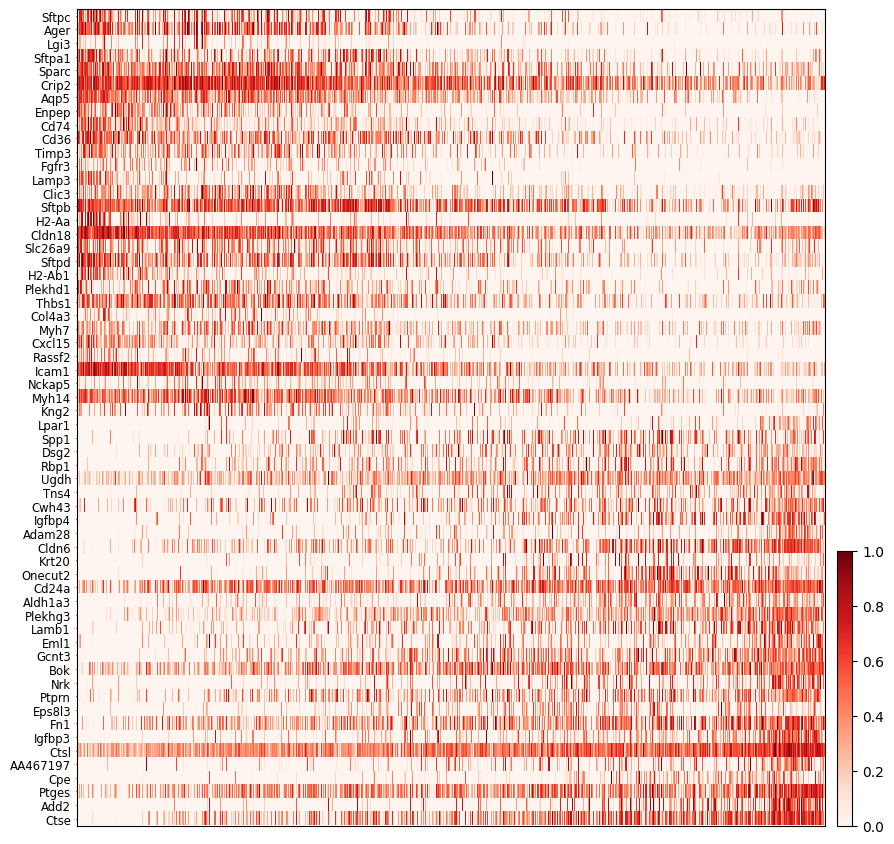

In [42]:
# PrE 相关基因
genes_pre = driver_result.sort_values(by='EMT_fate',ascending=False).head(30).index.tolist()

# EPI 相关基因
genes_epi = driver_result.sort_values(by='AT1_fate',ascending=False).head(30).index.tolist()
import numpy as np
adata = dmt.treedata.get_node('Transitional',adata_object=True).copy()
# 按 fate_score 从低到高排序
adata_sorted = adata[adata.obs['fate_bias'].argsort()].copy()
genes_all = genes_epi + genes_pre[::-1]
import scanpy as sc
adata_sorted.obs['all_cells'] = 'Transitional'
sc.pl.heatmap(
    adata_sorted,
    var_names=genes_all,
    groupby='all_cells',
    swap_axes=True,        # 基因在 y 轴
    standard_scale="var",  # 强烈推荐
    show_gene_labels=True,
    cmap="Reds",         # 可选，默认也可以
    show=False
)
plt.savefig(f"./LC.top_sig_heatmap.pdf",bbox_inches='tight')
plt.show()

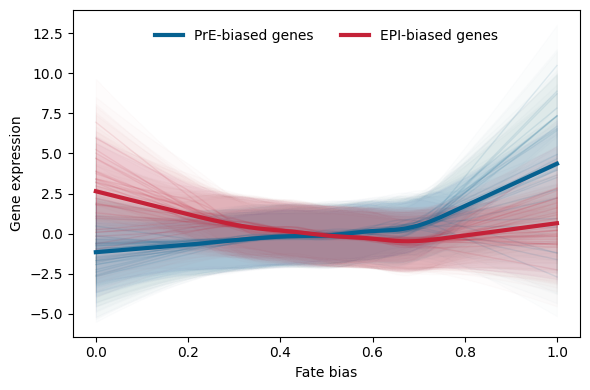

In [37]:
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

# ------------------
# gene class & colors
# ------------------
gene_class = {}
for g in genes_pre:
    gene_class[g] = 'pre'
for g in genes_epi:
    gene_class[g] = 'epi'

colors = {
    'pre': '#066190',   # PrE
    'epi': '#c42238'    # EPI
}
# ------------------
# x axis
# ------------------
x = adata.obs['fate_bias'].values
x_grid = np.linspace(0, 1, 200)

# ------------------
# store class-level predictions
# ------------------
class_preds = {
    'pre': [],
    'epi': []
}

plt.figure(figsize=(6, 4))

# ------------------
# per-gene GAM fitting
# ------------------
for gene in genes_pre + genes_epi:
    y = adata[:, gene].X
    if hasattr(y, "toarray"):
        y = y.toarray().flatten()
    else:
        y = y.flatten()

    # gene-wise scaling
    y = StandardScaler().fit_transform(y[:, None]).flatten()

    gam = LinearGAM(s(0, n_splines=10)).fit(x[:, None], y)

    y_pred = gam.predict(x_grid)
    y_ci = gam.prediction_intervals(x_grid, width=0.95)

    cls = gene_class[gene]
    c = colors[cls]

    # store prediction for class-average curve
    class_preds[cls].append(y_pred)

    # 置信区间（最底层）
    plt.fill_between(
        x_grid,
        y_ci[:, 0],
        y_ci[:, 1],
        color=c,
        alpha=0.01,
        zorder=1
    )

    # 单基因趋势线（浅色，中层）
    plt.plot(
        x_grid,
        y_pred,
        color=c,
        alpha=0.1,
        linewidth=1,
        zorder=2
    )

# ------------------
# class-average curves（深色，最上层）
# ------------------
for cls in ['pre', 'epi']:
    mean_pred = np.mean(class_preds[cls], axis=0)
    plt.plot(
        x_grid,
        mean_pred,
        color=colors[cls],
        linewidth=3,
        alpha=1.0,
        zorder=5
    )

# ------------------
# legend
# ------------------
legend_elements = [
    Line2D([0], [0], color=colors['pre'], lw=3, label='PrE-biased genes'),
    Line2D([0], [0], color=colors['epi'], lw=3, label='EPI-biased genes')
]

plt.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False
)


# ------------------
# labels & layout
# ------------------
plt.xlabel("Fate bias")
plt.ylabel("Gene expression")

plt.tight_layout()
#plt.savefig(f"./Fig4/LC.top_sig_trends.png",bbox_inches='tight')
plt.show()


In [59]:
import pandas as pd
driver_result.to_csv('./LUAD.driver.csv')

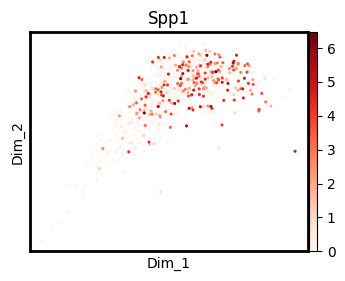

In [67]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
gene='Spp1'
with rc_context({'figure.figsize': (4, 3)}):
    ax = sc.pl.scatter(
            adata,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=20,
            color_map='Reds',
            frameon=False,
            show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.savefig(f"./LC.{gene}_featureplot.png",bbox_inches='tight')
    plt.show()

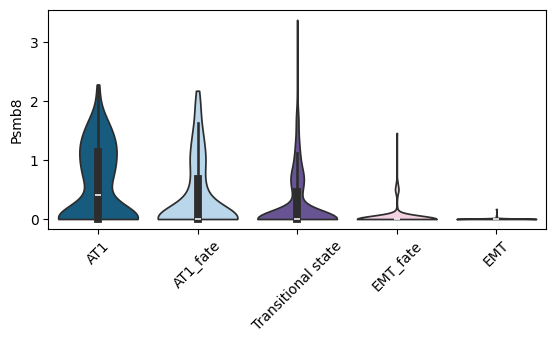

In [40]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

#tree = sc.read('./Fig4/LC_dmt.h5ad')
#stem = sc.read('D:/scRNA/LungCancer/Result.DyMoTree.10.14/transitional_dmt.h5ad')
gene = 'Psmb8'
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        adata_to_plot,
        gene,
        groupby='Fate_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig(f"./Fig4/LC.{gene}_expression_fate_State.png",bbox_inches='tight')
    plt.show()

In [41]:
import scanpy as sc

# 定义基因集
gene_sets = {
    'GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION': [
        '2410137M14Rik','Abcc1','Ap3b1','Ap3d1','Arl8b','Atg5','Azgp1','B2m','Bag6','Calr','Ccl19','Ccl21a','Ccr7',
        'Cd1d1','Cd1d2','Cd68','Cd74','Clec4a2','Clec4a3','Clec4a4','Clec4b2','Ctse','Ctsl','Ctss','Ext1','Fam3d',
        'Fcer1g','Fcer2a','Fcgr1','Fcgr2b','Fcgr3','Fcgr4','Fgl2','Flt3','Gba1','H2-Aa','H2-Ab1','H2-D1','H2-DMa',
        'H2-DMb1','H2-DMb2','H2-Ea','H2-Eb1','H2-Eb2','H2-K1','H2-M1','H2-M10.1','H2-M10.2','H2-M10.3','H2-M10.4',
        'H2-M10.5','H2-M10.6','H2-M11','H2-M2','H2-M3','H2-M5','H2-M9','H2-Oa','H2-Ob','H2-Q1','H2-Q10','H2-Q2',
        'H2-Q4','H2-Q6','H2-Q7','H2-T13','H2-T15','H2-T22','H2-T23','H2-T24','H2-T3','H2-T5','H60b','H60c','Hfe',
        'Icam1','Ide','Ifi30','Ifng','Ighe','Ighm','Kdm5d','Lgmn','Marchf1','Marchf8','Mfsd6','Mpeg1','Mr1','Nod1',
        'Nod2','Pdia3','Pikfyve','Psap','Psmb8','Psmb9','Psme1','Psme2','Ptpn22','Pycard','Rab10','Rab27a','Rab32',
        'Rab33a','Rab34','Rab35','Rab3b','Rab3c','Rab4a','Rab5b','Rab6a','Rab8b','Raet1d','Raet1e','Relb','Rftn1',
        'Slc11a1','Tap1','Tap2','Tapbp','Tapbpl','Thbs1','Traf6','Trem2','Treml4','Trex1','Ulbp1','Unc93b1','Was',
        'Washc1','Wdfy4','Ythdf1'
    ]
}

# 遍历并打分
for name, genes in gene_sets.items():
    genes_in_data = [g for g in genes if g in adata.var_names]
    if len(genes_in_data) == 0:
        print(f"⚠️ No genes found in adata for {name}")
        continue
    print(f"Scoring {name} using {len(genes_in_data)} genes...")
    sc.tl.score_genes(adata_to_plot, gene_list=genes_in_data, score_name=name)


Scoring GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION using 24 genes...


/tmp/ipykernel_2227165/1159736744.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


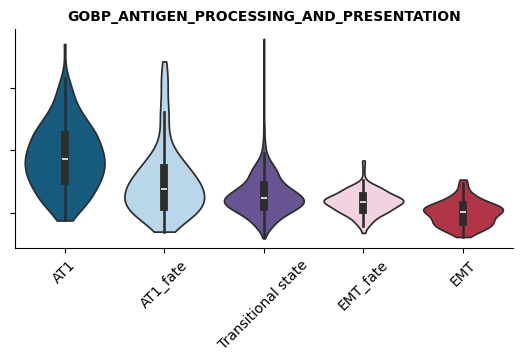

In [42]:
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context

gene = 'GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION'

with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        adata_to_plot,
        gene,
        groupby='Fate_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )

    # 移除 x 轴标签（避免名称过长挤压图形）
    ax.set_ylabel("")
    ax.set_yticklabels([])   # 或者直接隐藏横轴刻度标签

    # 在图像顶部添加标题
    plt.title(gene, fontsize=10, fontweight='bold', loc='center')

    # 可选：调整图像边距，避免标题与图形重叠
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 显示或保存
    #plt.savefig(f"./Fig4/LC.{gene}_expression_fate_State.pdf", bbox_inches='tight')
    plt.show()


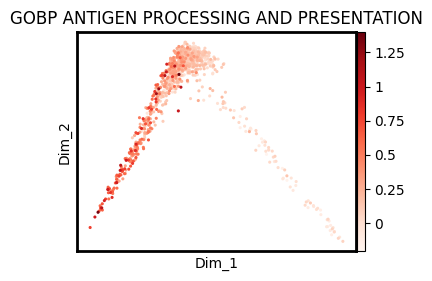

In [43]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
gene='GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION'
with rc_context({'figure.figsize': (4, 3)}):
    ax = sc.pl.scatter(
            adata_to_plot,
            x='Dim_1',
            y='Dim_2',
            color=gene, 
            size=20,
            color_map='Reds',
            frameon=False,
            show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    #plt.savefig(f"./Fig4/LC.{gene}_featureplot.pdf",bbox_inches='tight')
    plt.show()

gene.txt 中基因数: 28
在表达矩阵中匹配到的基因数: 28
未匹配到的基因数: 0

每个样本的基因集得分预览：
   Stage  GeneSet_Score
0      1       8.642459
1      0       8.023749
2      1       8.540966
3      0       9.398167
4      1       8.232906

各组统计：
           mean       std  count       sem  ci_lower  ci_upper
Stage                                                         
0      8.269712  0.534624    275  0.032239  8.206524  8.332901
1      8.415554  0.577731    235  0.037687  8.341687  8.489420

统计检验方法: Welch's t-test
统计量: -2.9407
P值: 0.003433


/tmp/ipykernel_2275821/1845181136.py:164: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2275821/1845181136.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_2275821/1845181136.py:189: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(display_labels)


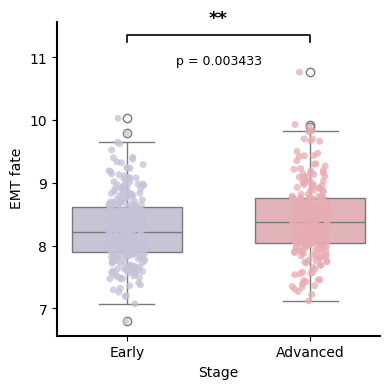


图片已保存到: Stage_EMT_gene_set_score_plot.png


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# =========================
# 1. 参数设置
# =========================
data_file = "processed_tcga_luad.csv"   # 你的总表
gene_file = "emt_gene.txt"                       # 基因列表
group_col = "Stage"                       # 指定分组列，可改成 Stage / Status 等
score_name = "GeneSet_Score"                 # 计算出的基因集得分列名
ylabel = "EMT fate"                    # y轴标题
plot_title = None                            # 图标题；None 表示不显示

# 分组标签映射（可选）
# 如果 group_col 是 0/1，可以自定义显示名称
group_label_map = {
    0: "Early",
    1: "Advanced"
}

# 输出图片
output_plot = f"{group_col}_EMT_gene_set_score_plot.png"

# =========================
# 2. 读取数据
# =========================
# 自动兼容 csv / tsv
if data_file.endswith(".tsv") or data_file.endswith(".txt"):
    expression_df_final = pd.read_csv(data_file, sep="\t")
else:
    expression_df_final = pd.read_csv(data_file)

# 统一列名为字符串，避免数字列名匹配出错
expression_df_final.columns = expression_df_final.columns.astype(str)

# 读取 gene.txt
with open(gene_file, "r", encoding="utf-8") as f:
    gene_list = [line.strip() for line in f if line.strip()]

gene_list = [str(g) for g in gene_list]

# =========================
# 3. 检查分组列
# =========================
if group_col not in expression_df_final.columns:
    raise ValueError(f"分组列 '{group_col}' 不在数据表中。可用列包括：{expression_df_final.columns.tolist()[:20]} ...")

# =========================
# 4. 提取基因列
# =========================
available_genes = [g for g in gene_list if g in expression_df_final.columns]
missing_genes = [g for g in gene_list if g not in expression_df_final.columns]

print(f"gene.txt 中基因数: {len(gene_list)}")
print(f"在表达矩阵中匹配到的基因数: {len(available_genes)}")
print(f"未匹配到的基因数: {len(missing_genes)}")

if len(available_genes) == 0:
    raise ValueError("gene.txt 中没有任何基因匹配到表达矩阵列名，请检查 gene.txt 与数据列名是否一致。")

if len(missing_genes) > 0:
    print("未匹配到的前10个基因：", missing_genes[:10])

# =========================
# 5. 计算每个样本的基因集得分
# =========================
# 强制转数值
expression_df_final[available_genes] = expression_df_final[available_genes].apply(pd.to_numeric, errors="coerce")

# 默认使用均值打分
expression_df_final[score_name] = expression_df_final[available_genes].mean(axis=1)
# log 转换（推荐）
expression_df_final[score_name] = np.log1p(expression_df_final[score_name])

print("\n每个样本的基因集得分预览：")
print(expression_df_final[[group_col, score_name]].head())

# =========================
# 6. 清理分组列和得分列缺失值
# =========================
plot_df = expression_df_final[[group_col, score_name]].copy()
plot_df = plot_df.dropna(subset=[group_col, score_name])

# 尝试把 group_col 转成更稳定的类型
# 若是 0/1，会保持数值；若是字符串分组，也支持
try:
    plot_df[group_col] = pd.to_numeric(plot_df[group_col])
except:
    pass

# =========================
# 7. 分组统计
# =========================
group_stats = plot_df.groupby(group_col)[score_name].agg(['mean', 'std', 'count'])
group_stats['sem'] = group_stats['std'] / np.sqrt(group_stats['count'])
group_stats['ci_lower'] = group_stats['mean'] - 1.96 * group_stats['sem']
group_stats['ci_upper'] = group_stats['mean'] + 1.96 * group_stats['sem']

print("\n各组统计：")
print(group_stats)

# =========================
# 8. 统计检验
# =========================
unique_groups = sorted(plot_df[group_col].dropna().unique().tolist())

if len(unique_groups) == 2:
    group0_scores = plot_df[plot_df[group_col] == unique_groups[0]][score_name]
    group1_scores = plot_df[plot_df[group_col] == unique_groups[1]][score_name]
    stat, p_value = stats.ttest_ind(group0_scores, group1_scores, equal_var=False)
    test_name = "Welch's t-test"
elif len(unique_groups) > 2:
    score_lists = [plot_df[plot_df[group_col] == g][score_name] for g in unique_groups]
    stat, p_value = stats.f_oneway(*score_lists)
    test_name = "One-way ANOVA"
else:
    raise ValueError("分组数不足，无法统计检验。")

print(f"\n统计检验方法: {test_name}")
print(f"统计量: {stat:.4f}")
print(f"P值: {p_value:.4g}")

def get_significance_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

significance = get_significance_stars(p_value)

# =========================
# 9. 处理x轴标签
# =========================
display_groups = unique_groups.copy()
display_labels = []

for g in display_groups:
    if g in group_label_map:
        display_labels.append(group_label_map[g])
    else:
        display_labels.append(str(g))

# 为了保证作图顺序一致
plot_df[group_col] = pd.Categorical(plot_df[group_col], categories=display_groups, ordered=True)

# =========================
# 10. 绘图
# =========================
plt.figure(figsize=(4, 4))

# 自动配色
if len(display_groups) == 2:
    palette = ['#c5c1d8', '#e8acb3']
else:
    palette = sns.color_palette("Set2", len(display_groups))

ax = sns.boxplot(
    data=plot_df,
    x=group_col,
    y=score_name,
    palette=palette,
    width=0.6
)

sns.stripplot(
    data=plot_df,
    x=group_col,
    y=score_name,
    palette=palette,
    alpha=0.75,
    jitter=True,
    size=5,
    ax=ax
)

plt.xlabel(group_col, fontsize=10)
plt.ylabel(ylabel, fontsize=10)

if plot_title is not None:
    plt.title(plot_title, fontsize=12)

ax.set_xticklabels(display_labels)

# =========================
# 11. 添加显著性标记
# =========================
y_max = plot_df[score_name].max()
y_min = plot_df[score_name].min()
y_range = y_max - y_min if y_max > y_min else 1
y_position = y_max + 0.15 * y_range

if len(display_groups) == 2:
    plt.plot(
        [0, 0, 1, 1],
        [y_position - 0.03 * y_range, y_position, y_position, y_position - 0.03 * y_range],
        color='black',
        lw=1.2
    )
    plt.text(
        0.5, y_position + 0.03 * y_range,
        significance,
        ha='center', va='bottom',
        fontweight='bold', fontsize=13
    )
    plt.text(
        0.5, y_position - 0.08 * y_range,
        f'p = {p_value:.4g}',
        ha='center', va='top',
        fontsize=9
    )
else:
    plt.text(
        0.5, 1.02,
        f"{test_name}, p = {p_value:.4g} ({significance})",
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=10
    )

# 边框样式
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('white')
ax.spines['top'].set_color('white')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig(output_plot, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n图片已保存到: {output_plot}")

标签分布：
Stage
0    275
1    235
Name: count, dtype: int64

gene.txt 基因数: 28
匹配到的基因数: 28
未匹配到的基因数: 0

用于建模的样本数: 510
用于建模的特征数: 28
Fold 1: AUC = 0.520
Fold 2: AUC = 0.606
Fold 3: AUC = 0.591
Fold 4: AUC = 0.552
Fold 5: AUC = 0.602

Logistic regression - ROC AUC: 0.574 (±0.033)
每折AUC: [0.52, 0.606, 0.591, 0.552, 0.602]
Fold 1: AUC = 0.653
Fold 2: AUC = 0.510
Fold 3: AUC = 0.528
Fold 4: AUC = 0.551
Fold 5: AUC = 0.725
Random gene - ROC AUC: 0.593 (±0.082)


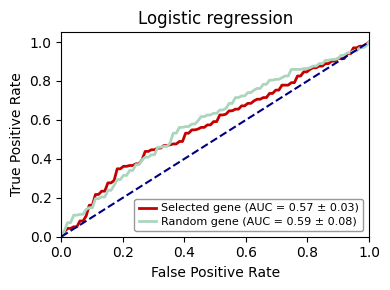

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# =========================
# 1. 参数设置
# =========================

data_file = "processed_tcga_luad.csv"   # 你的总表
gene_file = "emt_gene.txt"                       # 一行一个基因
label_col = "Stage"                       # 分类标签列，可改成 "label"
n_splits = 5
random_state = 123
output_fig = "logistic_regression_roc.pdf"

# 如果你的临床列有这些，可在这里排除
clinical_cols = ["Status", "Stage", "TP53_Mut", "Overall Survival (Months)"]

# =========================
# 2. 读取数据
# =========================
if data_file.endswith(".tsv") or data_file.endswith(".txt"):
    df = pd.read_csv(data_file, sep="\t")
else:
    df = pd.read_csv(data_file)

df.columns = df.columns.astype(str)

with open(gene_file, "r", encoding="utf-8") as f:
    gene_list = [line.strip() for line in f if line.strip()]

gene_list = [str(g) for g in gene_list]

# =========================
# 3. 检查标签列
# =========================
if label_col not in df.columns:
    raise ValueError(f"标签列 '{label_col}' 不存在。当前列包括：{df.columns.tolist()[:20]} ...")

# 转成数值型标签
df[label_col] = pd.to_numeric(df[label_col], errors="coerce")
df = df.dropna(subset=[label_col]).copy()
df[label_col] = df[label_col].astype(int)

# 仅保留 0/1
df = df[df[label_col].isin([0, 1])].copy()

print("标签分布：")
print(df[label_col].value_counts())

# =========================
# 4. 从数据中提取 gene.txt 对应的特征
# =========================
available_genes = [g for g in gene_list if g in df.columns]
missing_genes = [g for g in gene_list if g not in df.columns]

print(f"\ngene.txt 基因数: {len(gene_list)}")
print(f"匹配到的基因数: {len(available_genes)}")
print(f"未匹配到的基因数: {len(missing_genes)}")

if len(available_genes) == 0:
    raise ValueError("gene.txt 中没有任何基因能匹配到数据列名。")

# 只保留特征列
X = df[available_genes].copy()
X = X.apply(pd.to_numeric, errors="coerce")

# 删除有缺失值的样本
valid_idx = X.notna().all(axis=1)
X = X.loc[valid_idx].copy()
y = df.loc[valid_idx, label_col].copy()

print(f"\n用于建模的样本数: {X.shape[0]}")
print(f"用于建模的特征数: {X.shape[1]}")

# =========================
# 5. 五折交叉验证 ROC
# =========================
def five_fold_cv_roc(X, y, n_splits=5, random_state=123):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 标准化 + 逻辑回归
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs.append(interp_tpr)
        aucs.append(auc)

        print(f"Fold {fold}: AUC = {auc:.3f}")

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    return mean_fpr, mean_tpr, mean_auc, std_auc, aucs

fpr, tpr, roc_auc, roc_auc_std, fold_aucs = five_fold_cv_roc(
    X, y, n_splits=n_splits, random_state=random_state
)

print(f"\nLogistic regression - ROC AUC: {roc_auc:.3f} (±{roc_auc_std:.3f})")
print("每折AUC:", [round(x, 3) for x in fold_aucs])



# =========================
# 7. 随机基因集对照
# =========================
np.random.seed(123)

all_gene_cols = [c for c in df.columns if c not in clinical_cols]
all_gene_cols = [g for g in all_gene_cols if g not in available_genes]

random_genes = np.random.choice(all_gene_cols, size=len(available_genes), replace=False).tolist()

X_random = df.loc[valid_idx, random_genes].copy()
X_random = X_random.apply(pd.to_numeric, errors="coerce")

valid_idx_random = X_random.notna().all(axis=1)
X_random = X_random.loc[valid_idx_random].copy()
y_random = df.loc[valid_idx, label_col].loc[valid_idx_random].copy()

fpr1, tpr1, roc_auc1, roc_auc_std1, fold_aucs1 = five_fold_cv_roc(
    X_random, y_random, n_splits=n_splits, random_state=random_state
)

print(f"Random gene - ROC AUC: {roc_auc1:.3f} (±{roc_auc_std1:.3f})")

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color="#c50000", lw=2,
         label=f"Selected gene (AUC = {roc_auc:.2f} ± {roc_auc_std:.2f})")
plt.plot(fpr1, tpr1, color="#abd5bd", lw=2,
         label=f"Random gene (AUC = {roc_auc1:.2f} ± {roc_auc_std1:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic regression")

plt.legend(
    loc="lower right",
    fontsize=8,
    frameon=True,
    fancybox=True,
    framealpha=0.8,
    edgecolor="gray",
    handlelength=1.5,
    handletextpad=0.5,
    borderpad=0.4,
    labelspacing=0.3
)

plt.tight_layout()
plt.show()